# 05 · Segmentación por densidad de buró + validación temporal
## Tesis UBA 2026 — LLMs vs. ML Clásico para Credit Scoring

Este es el notebook **conceptualmente central** del trabajo: define la segmentación
*esparso/denso* que usamos en todos los experimentos, y corrige el protocolo de
validación. La lógica vive en `scripts/05_segmentacion_thin_file.py` (`segment_cv`).

---
## ¿Qué es el segmento "esparso" (thin-file) y por qué importa?

El **buró de crédito TransUnion** aporta 20 variables (mora histórica, saldos, antigüedad
de cuentas, diversificación sectorial). Cuando un cliente **no tiene obligaciones de cierto
tipo registradas en el buró**, esas variables vienen con un código negativo (−1, −2, −3)
que significa *"sin ese tipo de obligación"* — no es un dato faltante convencional, es
ausencia de historial.

Definimos el **conteo de variables TU con valor −1** por cliente y partimos en dos:

- **Esparso (thin-file): ≥ 6 variables TU en −1** (~44% del dataset). Cliente con historial
  crediticio formal **fragmentado o inexistente**. El buró aporta poca señal numérica.
- **Denso (full-file): < 6 variables TU en −1** (~56%). Cliente con historial TU completo,
  donde los modelos clásicos tienen ventaja informativa.

**¿Por qué es la partición clave de la tesis?** La hipótesis central es que el LLM debería
aportar **más en el segmento esparso**: cuando la señal numérica del buró es débil, la
**señal semántica** del texto (rubro del negocio, descripción, perfil) gana peso relativo.
Si el LLM gana en algún lado, debería ser acá. Por eso reportamos siempre las métricas
separadas por segmento.

---
## ¿Por qué cambiamos StratifiedKFold → TimeSeriesSplit?

La versión previa usaba `StratifiedKFold(shuffle=True)`. En datos con estructura temporal
**eso es incorrecto**: el barajado mezcla créditos de 2022 y 2024 en el mismo *fold*, de
modo que el modelo **entrena con el futuro para predecir el pasado** (*data leakage*
temporal). El resultado son métricas infladas que no se sostienen fuera de muestra.

Lo reemplazamos por **`TimeSeriesSplit` (5 splits)** ordenando por `fecha_desembolso`:
cada *fold* entrena sobre el pasado y valida sobre el bloque siguiente (Bergmeir &
Benítez, 2012). Veremos abajo cuánto bajan las métricas — ese delta **es** el leakage que
teníamos antes.

In [1]:
import importlib.util
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image


def _find_base() -> Path:
    base = Path.cwd()
    while not (base / "scripts").exists() and base != base.parent:
        base = base.parent
    return base


BASE = _find_base()


def load_script(filename: str):
    path = BASE / "scripts" / filename
    spec = importlib.util.spec_from_file_location("s_" + filename[:2], path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

## Tamaño de cada segmento
Verificamos la proporción esparso/denso y su tasa de default.

In [2]:
m05 = load_script("05_segmentacion_thin_file.py")
# load_segmented retorna (df ordenado por fecha, lista de features)
df, features = m05.load_segmented(str(BASE / "data" / "dataset_tesis.csv"))
resumen = (df.groupby("segmento")
           .agg(n=("target", "size"), default_rate=("target", "mean"),
                tu_missing_prom=("n_tu_missing", "mean"))
           .round(3))
resumen["pct"] = (resumen["n"] / len(df) * 100).round(1)
resumen

,n,default_rate,tu_missing_prom,pct
segmento,,,,
denso,3440,0.602,3.152,64.3
esparso,1911,0.279,7.610,35.7


## Ejecución de la validación temporal por segmento

In [3]:
cv = m05.segment_cv(
    dataset_path=str(BASE / "data" / "dataset_tesis.csv"),
    output_dir=str(BASE / "models"),
)

# Tabla AUC media ± std por modelo y segmento
filas = []
for modelo in ("XGBoost", "LogReg"):
    for seg in ("esparso", "denso", "total"):
        s = cv[modelo].get(seg)
        if s and "AUC" in s:
            filas.append({"modelo": modelo, "segmento": seg,
                          "AUC": round(s["AUC"]["mean"], 3),
                          "±std": round(s["AUC"]["std"], 3),
                          "n_folds": s.get("n_folds")})
pd.DataFrame(filas)

,modelo,segmento,AUC,±std,n_folds
0,XGBoost,esparso,0.704,0.087,5
1,XGBoost,denso,0.739,0.133,5
2,XGBoost,total,0.712,0.131,5
3,LogReg,esparso,0.711,0.087,5
4,LogReg,denso,0.683,0.058,5
5,LogReg,total,0.688,0.071,5


## Composición temporal de los folds
Confirma el *confound* temporal: los esparsos se concentran en los primeros folds (2022)
y casi desaparecen en los últimos — por eso el N por segmento varía entre folds.

In [4]:
pd.DataFrame(cv["_fold_composition"]).rename_axis("fold").rename(lambda i: f"fold {i+1}")

,esparso,denso
fold,,
fold 1,312,579
fold 2,424,467
fold 3,326,565
fold 4,69,822
fold 5,66,825


## El costo del data leakage: barajado vs. temporal
Contraste con los valores que daba el `StratifiedKFold` barajado (entregas previas).

In [5]:
inflado = {("XGBoost", "esparso"): 0.873, ("XGBoost", "denso"): 0.945,
           ("LogReg", "esparso"): 0.808, ("LogReg", "denso"): 0.835}
comp = []
for (modelo, seg), viejo in inflado.items():
    nuevo = cv[modelo][seg]["AUC"]["mean"]
    comp.append({"modelo": modelo, "segmento": seg,
                 "CV barajado (inflado)": viejo,
                 "CV temporal (honesto)": round(nuevo, 3),
                 "Δ (leakage)": round(nuevo - viejo, 3)})
pd.DataFrame(comp)

,modelo,segmento,CV barajado (inflado),CV temporal (honesto),Δ (leakage)
0,XGBoost,esparso,0.873,0.704,-0.169
1,XGBoost,denso,0.945,0.739,-0.206
2,LogReg,esparso,0.808,0.711,-0.097
3,LogReg,denso,0.835,0.683,-0.152


## AUC por segmento (validación temporal)

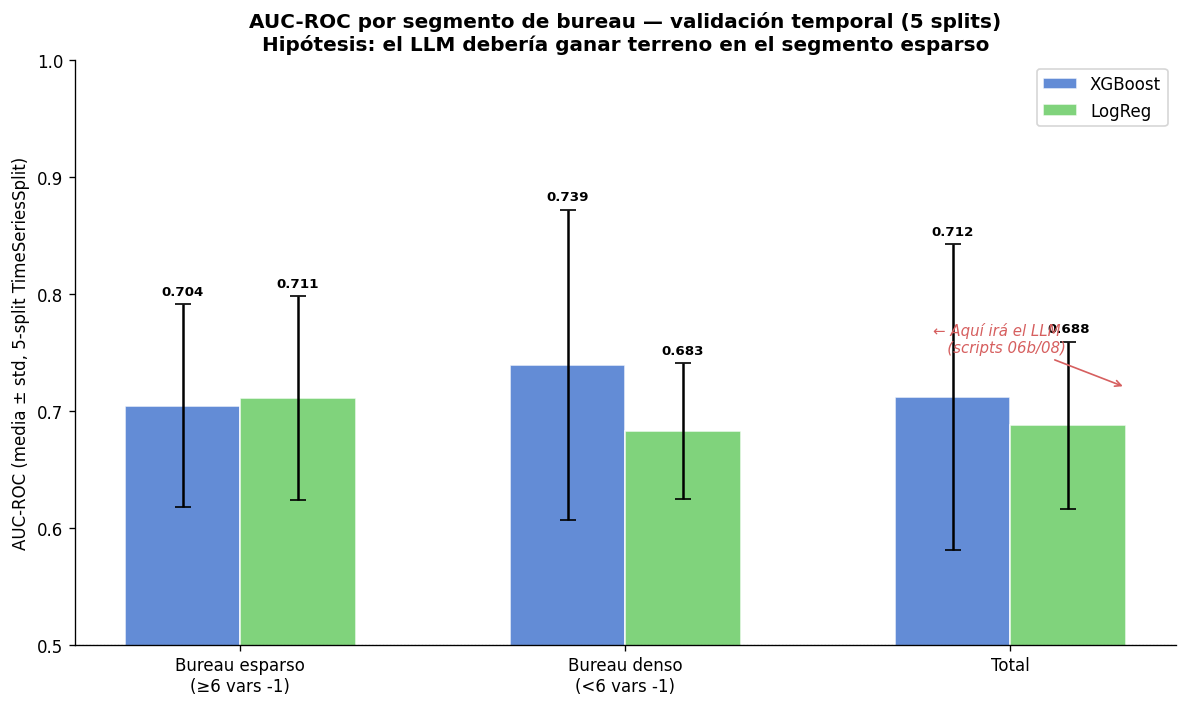

In [6]:
Image(filename=str(BASE / "figures" / "19_auc_por_segmento_cv.png"))

**Lectura.** El leakage inflaba el AUC entre 0.10 y 0.21. El AUC denso de XGBoost de
0.945 — que sugería un modelo casi perfecto — no se sostiene fuera de muestra. Además,
las desviaciones estándar crecen: la inestabilidad temporal real, que el barajado
ocultaba, ahora es visible. Estos números honestos son los que usamos en el documento E3.